# Demo: DriftInjector — Covariate Shift y Concept Drift en PhysioNet

Este notebook demuestra el uso de la clase `DriftInjector` para simular tanto **Covariate Shift** como **Concept Drift** sobre el dataset de sepsis (PhysioNet) de forma independiente o simultánea.


### 1. Covariate Shift Numérico (Mixtura Beta)

El _covariate shift_ simula un cambio en la distribución marginal de características, $P(X)$, manteniendo constante la distribución condicional $P(Y|X)$. Para variables numéricas, aplicamos:

$$x_{\text{drift}, i} = m_i \cdot \tilde{x}_i + (1 - m_i) \cdot x_{\text{orig}, i}$$

Donde:

- $x_{\text{drift}, i}$ es el valor resultante tras la inyección de drift en el rango normalizado $[0, 1]$.
- $x_{\text{orig}, i}$ es el valor original normalizado.
- $\tilde{x}_i \sim \text{Beta}(\alpha_q, \beta_q)$ es una muestra de la distribución Beta objetivo.
- $m_i \sim \text{Bernoulli}(\gamma)$ determina si la observación $i$ sufre perturbación, donde $\gamma$ es el hiperparámetro `drift_severity`.

Para devolver los datos normalizados a su escala física original, usamos:

$$X_{\text{drift}, i} = x_{\text{drift}, i} \cdot (X_{\text{max}} - X_{\text{min}}) + X_{\text{min}}$$


### 2. Concept Drift Puro (Label Flipping)

El _concept drift_ simula un cambio en la distribución condicional, $P(Y|X)$, manteniendo constante la distribución marginal $P(X)$. Para variables binarias, aplicamos **inversión de etiquetas** (_label flipping_) aleatoria en la población:

$$Y_{\text{drift}, i} = \begin{cases} 1 - Y_i & \text{con probabilidad } p = 0.45 \cdot \gamma \\ Y_i & \text{con probabilidad } 1 - p \end{cases}$$

Donde:

- $Y_{\text{drift}, i} \in \{0, 1\}$ es la etiqueta después de aplicar el drift.
- $Y_i \in \{0, 1\}$ es la etiqueta binaria original de sepsis (`SepsisLabel`).
- $\gamma$ es el hiperparámetro `drift_severity`.
- El factor $0.45$ actúa como límite superior (_cap_ de 45%) para evitar invertir por completo la señal predictiva ($p > 0.50$ haría que el detector aprenda de forma inversa).

**Explicación conceptual:**
Dado que solo se invierten los labels y no se tocan los valores de las variables $X$, la distribución marginal de características $P(X)$ se mantiene idéntica, permitiendo aislar perfectamente el degradamiento del clasificador (Etapa 2) sin alterar el preprocesamiento (Etapa 1).


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from darl.data.get_dataset import load_dataset

from darl.drift import DriftInjector
from darl.visualization.drift_plots import plot_numeric_drift_grid

c:\Users\jeffr\GitHub\tesis-darl\.venv\Lib\site-packages\xport\__about__.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
print("Cargando PhysioNet...")
dset = load_dataset("physionet")

df_train, y_train, _, _ = dset.get_pandas("train")
df_target, y_target, _, _ = dset.get_pandas("id_test")

# Asegurar que la etiqueta objetivo está incluida en la estructura del DataFrame
LABEL_COL = "SepsisLabel"
if LABEL_COL not in df_train.columns:
    df_train[LABEL_COL] = y_train
if LABEL_COL not in df_target.columns:
    df_target[LABEL_COL] = y_target

print(f"Train : {df_train.shape}")
print(f"Target: {df_target.shape}")

Cargando PhysioNet...


c:\Users\jeffr\GitHub\tesis-darl\.venv\Lib\site-packages\sklearn\compose\_column_transformer.py:1590: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  df_row = df_row.select_dtypes(
c:\Users\jeffr\GitHub\tesis-darl\.venv\Lib\site-packages\sklearn\compose\_column_transformer.py:1590: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  df_row = df_row.select_dtypes(


Train : (1122299, 41)
Target: (140288, 41)


In [6]:
VITALS = ["HR", "SBP", "MAP", "Resp", "Temp"]

inj = DriftInjector(random_state=42)
inj.fit(df_train, numeric_cols=VITALS)
print("DriftInjector entrenado en datos de referencia.")

DriftInjector entrenado en datos de referencia.


## 3. Simulación: Covariate Shift Únicamente (Afecta Etapa 1)


Resumen de drift en covariables:


,type,drift_severity,direction,beta_orig,beta_target,ks_stat,ks_pval,psi
variable,,,,,,,,
HR,numeric,0.3,high,"(10.24, 31.14)","(5.00, 2.00)",0.283706,0.0,0.523610
SBP,numeric,0.3,low,"(12.45, 20.75)","(2.00, 5.00)",0.137605,0.0,0.429259
MAP,numeric,0.3,low,"(11.39, 39.83)","(2.00, 5.00)",0.097947,0.0,0.296363
Resp,numeric,0.3,high,"(9.39, 43.39)","(5.00, 2.00)",0.292141,0.0,2.255678
Temp,numeric,0.3,extreme,"(189.44, 153.77)","(0.50, 0.50)",0.148859,0.0,0.528636


Prevalencia de Sepsis original: 0.0120
Prevalencia de Sepsis post-drift: 0.0120


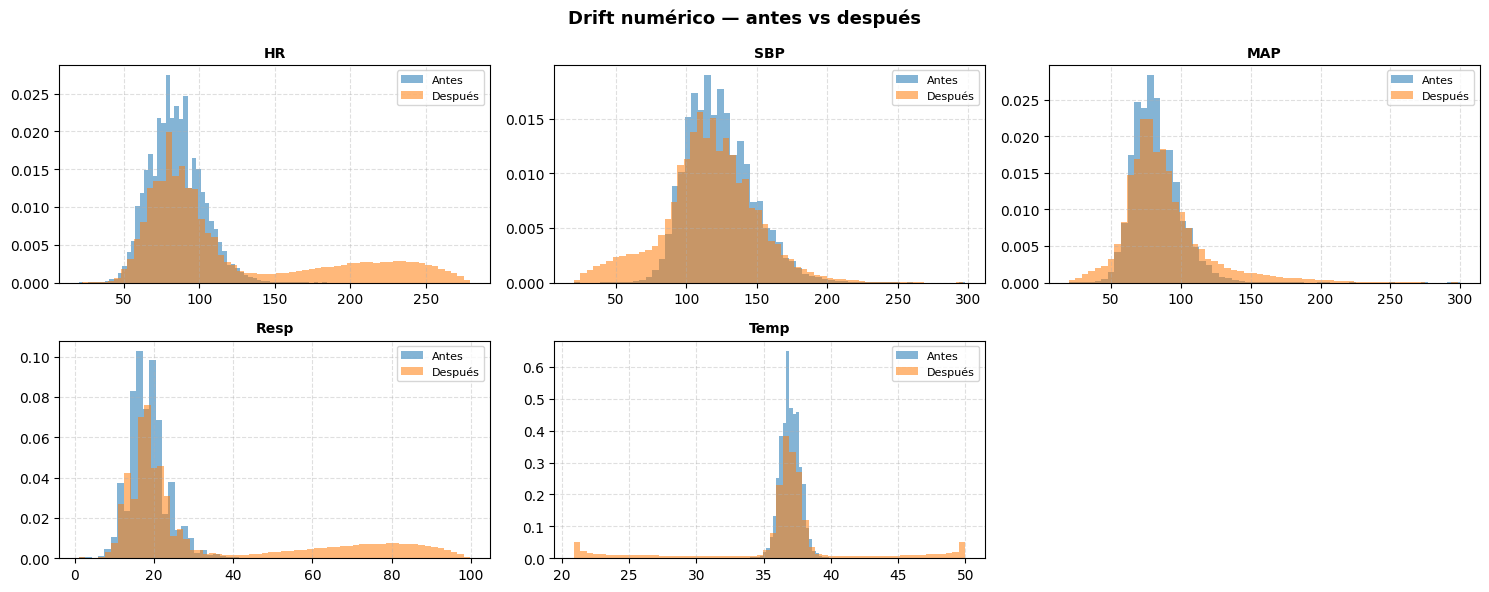

In [7]:
num_cfg = {
    "HR": "high",
    "SBP": "low",
    "MAP": "low",
    "Resp": "high",
    "Temp": "extreme",
}

df_cov, meta_cov = inj.transform(
    df_target, drift_severity=0.3, numeric_drift_config=num_cfg
)

print("Resumen de drift en covariables:")
display(DriftInjector.summary(meta_cov))
print(f"Prevalencia de Sepsis original: {df_target[LABEL_COL].mean():.4f}")
print(f"Prevalencia de Sepsis post-drift: {df_cov[LABEL_COL].mean():.4f}")

# Graficar distribución de covariables
fig_cov = plot_numeric_drift_grid(df_target, df_cov, cols=VITALS, ncols=3, bins=60)
plt.show()

## 4. Simulación: Concept Drift Únicamente (Afecta Etapa 2)


Resumen de drift de concepto (Labels):


,type,drift_severity,strategy,before_prev,after_prev,psi
variable,,,,,,
SepsisLabel,label,0.3,flip (p=0.14),0.012,0.144,0.0


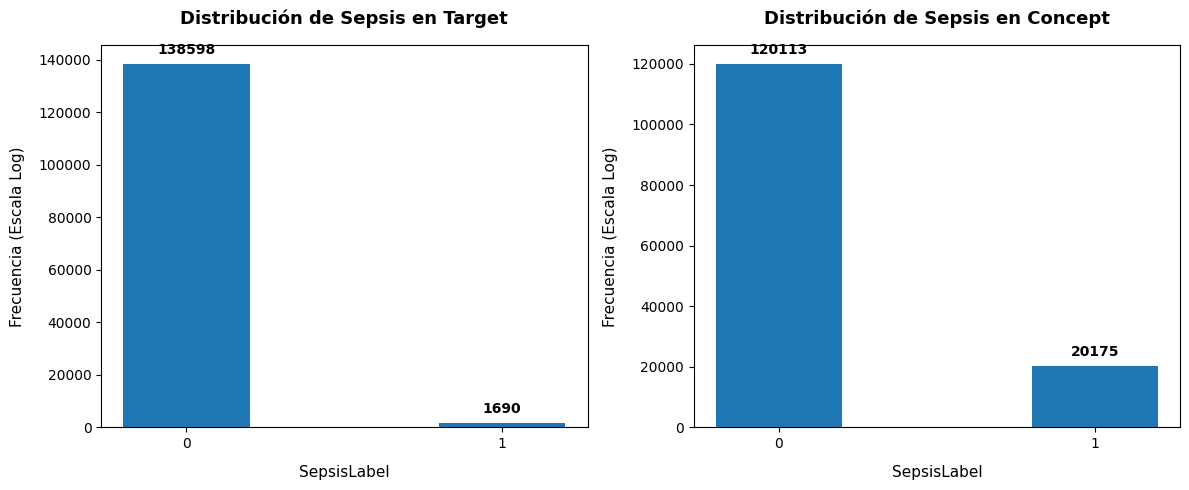

¿Son las covariables X idénticas al original? True


In [24]:
df_concept, meta_concept = inj.transform(
    df_target, drift_severity=0.3, label_col=LABEL_COL, drift_type="concept"
)

print("Resumen de drift de concepto (Labels):")
display(DriftInjector.summary(meta_concept))

counts_target = df_target[LABEL_COL].value_counts()
counts_concept = df_concept[LABEL_COL].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars_target = axes[0].bar(
    counts_target.index.astype(str), counts_target.values, width=0.4, color="tab:blue"
)
axes[0].bar_label(bars_target, fmt="%d", padding=5, fontsize=10, fontweight="bold")
axes[0].set_title(
    "Distribución de Sepsis en Target", fontsize=13, fontweight="bold", pad=15
)
axes[0].set_xlabel("SepsisLabel", fontsize=11, labelpad=10)
axes[0].set_ylabel("Frecuencia (Escala Log)", fontsize=11, labelpad=10)

bars_concept = axes[1].bar(
    counts_concept.index.astype(str), counts_concept.values, width=0.4, color="tab:blue"
)
axes[1].bar_label(bars_concept, fmt="%d", padding=5, fontsize=10, fontweight="bold")
axes[1].set_title(
    "Distribución de Sepsis en Concept", fontsize=13, fontweight="bold", pad=15
)
axes[1].set_xlabel("SepsisLabel", fontsize=11, labelpad=10)
axes[1].set_ylabel("Frecuencia (Escala Log)", fontsize=11, labelpad=10)

plt.tight_layout()
plt.show()

# Verificar que las características no se alteraron (P(X) constante)
are_features_equal = df_concept.drop(columns=[LABEL_COL]).equals(
    df_target.drop(columns=[LABEL_COL])
)
print(f"¿Son las covariables X idénticas al original? {are_features_equal}")

## 5. Simulación: Covariate Shift + Concept Drift Simultáneos


In [25]:
df_both, meta_both = inj.transform(
    df_target,
    drift_severity=0.4,
    numeric_drift_config=num_cfg,
    label_col=LABEL_COL,
    drift_type="both",
)

print("Resumen de drift conjunto (ambas etapas afectadas):")
display(DriftInjector.summary(meta_both))

Resumen de drift conjunto (ambas etapas afectadas):


,type,drift_severity,strategy,before_prev,after_prev,psi,direction,beta_orig,beta_target,ks_stat,ks_pval
variable,,,,,,,,,,,
SepsisLabel,label,0.4,flip (p=0.18),0.012,0.186,0.000000,NaN,NaN,NaN,NaN,NaN
HR,numeric,0.4,NaN,NaN,NaN,0.805118,high,"(10.24, 31.14)","(5.00, 2.00)",0.376529,0.0
SBP,numeric,0.4,NaN,NaN,NaN,0.625798,low,"(12.45, 20.75)","(2.00, 5.00)",0.180114,0.0
MAP,numeric,0.4,NaN,NaN,NaN,0.442395,low,"(11.39, 39.83)","(2.00, 5.00)",0.132246,0.0
Resp,numeric,0.4,NaN,NaN,NaN,3.172783,high,"(9.39, 43.39)","(5.00, 2.00)",0.389096,0.0
Temp,numeric,0.4,NaN,NaN,NaN,0.817050,extreme,"(189.44, 153.77)","(0.50, 0.50)",0.193153,0.0


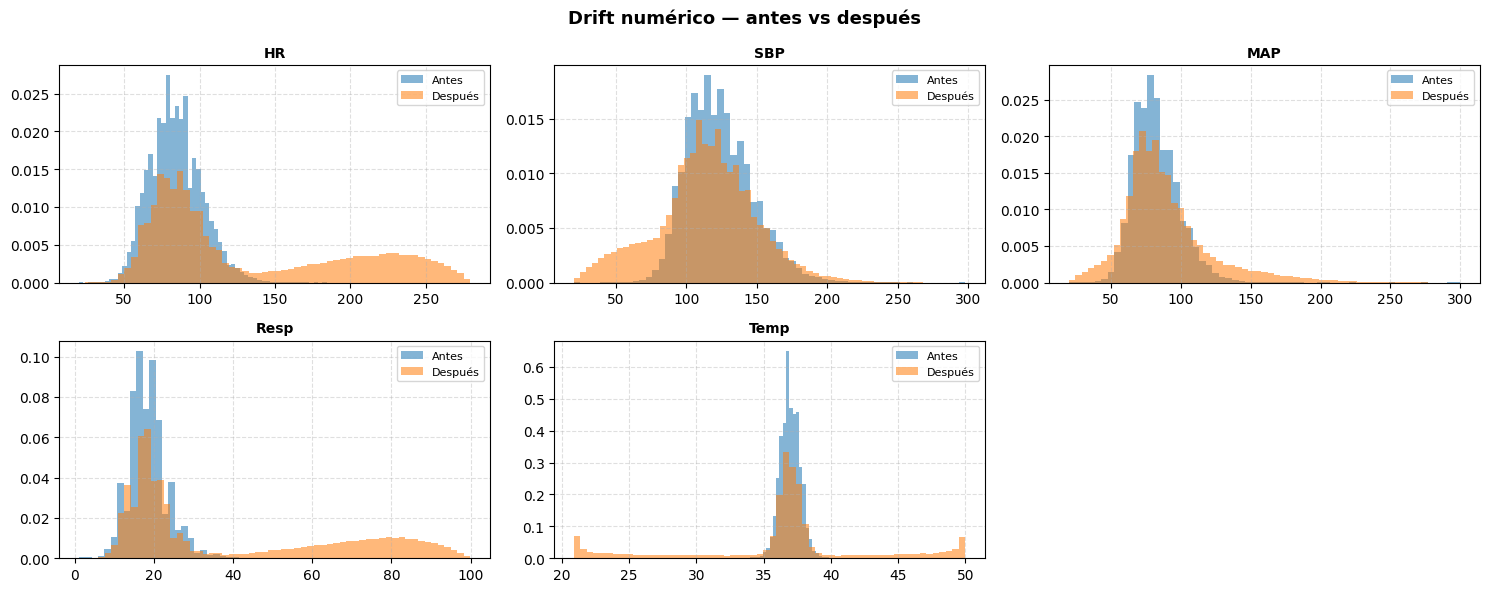

In [9]:
fig = plot_numeric_drift_grid(df_target, df_both, cols=VITALS, ncols=3, bins=60)
plt.show()

## 6. Visualización de la Distribución de Etiquetas tras Concept Drift


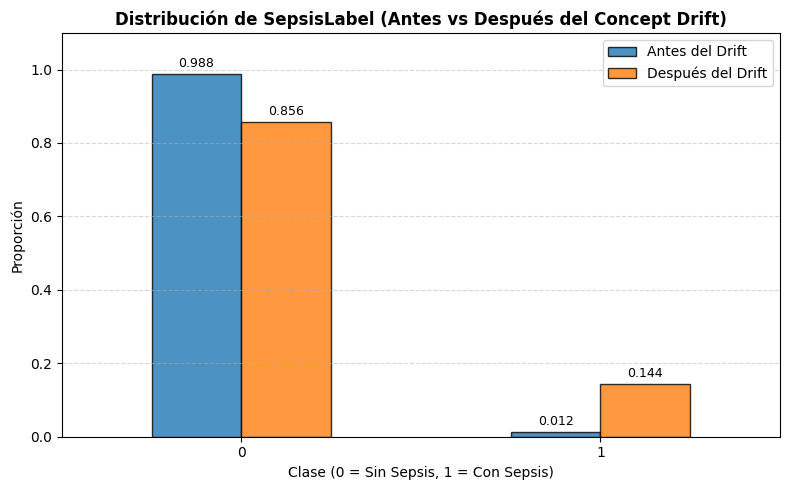

In [26]:
df_target_counts = df_target[LABEL_COL].value_counts(normalize=True).sort_index()
df_concept_counts = df_concept[LABEL_COL].value_counts(normalize=True).sort_index()

df_compare = pd.DataFrame(
    {"Antes del Drift": df_target_counts, "Después del Drift": df_concept_counts}
)

ax = df_compare.plot(
    kind="bar",
    color=["#1f77b4", "#ff7f0e"],
    alpha=0.8,
    edgecolor="black",
    figsize=(8, 5),
)

plt.title(
    "Distribución de SepsisLabel (Antes vs Después del Concept Drift)",
    fontsize=12,
    fontweight="bold",
)
plt.ylabel("Proporción", fontsize=10)
plt.xlabel("Clase (0 = Sin Sepsis, 1 = Con Sepsis)", fontsize=10)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.3f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height() + 0.01),
        ha="center",
        va="center",
        xytext=(0, 5),
        textcoords="offset points",
        fontsize=9,
    )

plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()